# Computer Vision & Speech Recognition — Homework Sessions 1-3, Part A
**Sebastián Ríos Saucedo** · EADA · MILK10k


In [1]:
import io
import os
import sys
import time
from pathlib import Path

# make the repo root importable, wherever the notebook is opened from
ROOT = Path.cwd()
while not (ROOT / "milk10k_pipeline").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from milk10k_pipeline import color_analysis as ca
from milk10k_pipeline import config, data, labels, quality, splits

SEED = config.SEED
pd.set_option("display.width", 140)
print(config.describe())

meta = data.load_metadata()           # one row per image
gt = data.load_gt()                   # one row per lesion (one-hot) + dx
images = data.load_images_table()     # metadata + dx
images["available"] = data.available_mask(images["isic_id"])
print(f"{len(meta)} image rows, {len(gt)} lesions, {images['available'].sum()} image files on disk")

DATA_DIR=C:\Users\Dell\OneDrive\Desktop\EADA\4th Year\Computer Vision & Speech Recognition\milk10k_project | IMAGE_DIR=C:\Users\Dell\OneDrive\Desktop\EADA\4th Year\Computer Vision & Speech Recognition\milk10k_project\images | SEED=42 | IMG_SIZE=224
10480 image rows, 5240 lesions, 10480 image files on disk


---
## A1. Session 1 — Trusting and shaping the data
### A1.1 Cross-check the two label files

In [2]:
class_cols = [c for c in gt.columns if c not in ("lesion_id", "dx")]

# (a) same set of lesion_id in both files
ids_meta, ids_gt = set(meta["lesion_id"]), set(gt["lesion_id"])
print(f"(a) lesions only in metadata: {len(ids_meta - ids_gt)}, only in gt: {len(ids_gt - ids_meta)}")
assert ids_meta == ids_gt

# (b) exactly one positive class per lesion
n_pos = gt[class_cols].sum(axis=1)
print(f"(b) lesions with != 1 positive class: {(n_pos != 1).sum()} (classes: {len(class_cols)})")
assert (n_pos == 1).all()

# (c) class -> diagnosis_1 (lesion counts)
c2d = quality.class_to_diagnosis1(images)
print("(c) class -> diagnosis_1, lesion counts:")
display(c2d)
not_unique = c2d[(c2d > 0).sum(axis=1) > 1]
print("    classes that do NOT map to exactly one diagnosis_1:")
print(not_unique.to_string() if len(not_unique) else "    none")

# (d) hierarchy diagnosis_3 -> diagnosis_2 -> diagnosis_1
v32 = quality.hierarchy_violations(images, "diagnosis_3", "diagnosis_2")
v21 = quality.hierarchy_violations(images, "diagnosis_2", "diagnosis_1")
print(f"(d) diagnosis_3 values with >1 diagnosis_2: {len(v32)} | diagnosis_2 values with >1 diagnosis_1: {len(v21)}")
assert v32.empty and v21.empty

# (e) both images of a lesion share age, sex, site and diagnosis fields
dis = quality.lesion_fields_consistency(images)
print("(e) lesions whose two images disagree, per field:\n", dis.to_string())
assert dis.sum() == 0

(a) lesions only in metadata: 0, only in gt: 0
(b) lesions with != 1 positive class: 0 (classes: 11)
(c) class -> diagnosis_1, lesion counts:


diagnosis_1,Benign,Indeterminate,Malignant
dx,,,
AKIEC,0,123,180
BCC,0,0,2522
BEN_OTH,44,0,0
BKL,544,0,0
DF,52,0,0
INF,50,0,0
MAL_OTH,0,0,9
MEL,0,0,450
NV,746,0,0


    classes that do NOT map to exactly one diagnosis_1:
diagnosis_1  Benign  Indeterminate  Malignant
dx                                           
AKIEC             0            123        180
(d) diagnosis_3 values with >1 diagnosis_2: 0 | diagnosis_2 values with >1 diagnosis_1: 0
(e) lesions whose two images disagree, per field:
 age_approx             0
sex                    0
anatom_site_general    0
diagnosis_1            0
diagnosis_2            0
diagnosis_3            0
diagnosis_4            0


**Answer A1.1.** Checks (a), (b), (d) and (e) pass: both files cover the same 5,240 lesions, the one-hot is clean, the diagnosis hierarchy is consistent and both images of a lesion have identical age, sex, site and diagnoses. Check (c) fails for one class: **AKIEC maps to two values of diagnosis_1**, 123 lesions are *Indeterminate* (actinic keratosis, "indeterminate epidermal proliferations") and 180 are *Malignant* (Bowen's disease / SCC in situ). The other 10 classes map to a single value. So diagnosis_1 can **not** be derived from an 11-class prediction: a predicted AKIEC is ambiguous. That is why the project's label strategy predicts diagnosis_1 directly, and also stratifies the split on `dx` refined by diagnosis_1. On any new medical dataset I would repeat all five checks before training: identifier matching, one-label-per-case, label hierarchy, the label mapping and per-patient/per-lesion consistency. The most dangerous failure is (a)/(e), i.e. IDs that do not match or two views of the "same" lesion disagreeing. It silently attaches the wrong label to images, and nothing downstream (loss, metrics) will ever reveal it.

### A1.2 Ask the data five questions

In [3]:
lesions = data.build_lesion_table(images)          # one row per lesion (see A1.3)

# 1. BCC lesions, age >= 70, head/neck
q1 = lesions.query("dx == 'BCC' and age >= 70 and site == 'head/neck'")
print(f"1. BCC lesions in patients >= 70 on head/neck: {len(q1)}")

# 2. class with the highest % of 'altered' images
alt = images.groupby("dx")["image_manipulation"].apply(lambda s: (s == "altered").mean() * 100)
print(f"2. highest % altered: {alt.idxmax()} with {alt.max():.1f}% of its images "
      f"(overall {100 * (images.image_manipulation == 'altered').mean():.1f}%)")

# 3. youngest / oldest melanoma patient
mel = lesions.loc[lesions.dx == "MEL", "age"]
print(f"3. MEL age: youngest {mel.min():.0f}, oldest {mel.max():.0f}, gap {mel.max() - mel.min():.0f} years")

# 4. is a missing site informative?
has_site = lesions["site"].notna().map({True: "with site", False: "without site"})
dist = pd.crosstab(lesions["dx"], has_site, normalize="columns") * 100
dist["diff_pp"] = dist["without site"] - dist["with site"]
print("4. class distribution (% of lesions) with vs without site:")
print(dist.round(2).sort_values("diff_pp").to_string())
print(f"   largest change: {dist['diff_pp'].abs().idxmax()} ({dist.loc[dist['diff_pp'].abs().idxmax(), 'diff_pp']:+.1f} pp)")

# 5. % malignant by confirmation type (lesion level)
les_conf = images.drop_duplicates("lesion_id")
q5 = (pd.crosstab(les_conf["diagnosis_confirm_type"], les_conf["diagnosis_1"], normalize="index") * 100).round(1)
q5["n_lesions"] = les_conf["diagnosis_confirm_type"].value_counts()
print("5. diagnosis_1 (% of lesions) by confirmation type:\n", q5.to_string())

1. BCC lesions in patients >= 70 on head/neck: 380
2. highest % altered: BEN_OTH with 18.2% of its images (overall 3.2%)
3. MEL age: youngest 20, oldest 85, gap 65 years
4. class distribution (% of lesions) with vs without site:
site     with site  without site  diff_pp
dx                                       
SCCKA        12.70          2.86    -9.83
AKIEC         8.01          2.04    -5.96
DF            1.31          0.46    -0.85
BKL          10.57         10.07    -0.49
INF           1.00          0.87    -0.14
BEN_OTH       0.88          0.77    -0.12
MAL_OTH       0.09          0.31     0.22
VASC          0.73          1.18     0.45
BCC          47.41         49.34     1.92
MEL           7.16         10.99     3.84
NV           10.14         21.11    10.97
   largest change: NV (+11.0 pp)
5. diagnosis_1 (% of lesions) by confirmation type:
 diagnosis_1                             Benign  Indeterminate  Malignant  n_lesions
diagnosis_confirm_type                                 

**Answer A1.2.** (1) 380 BCC lesions in patients aged 70+ on the head/neck. (2) BEN_OTH has the highest share of *altered* images (18.2% vs 3.2% overall). (3) Melanoma patients range from 20 to 85 years, a 65-year gap.

**(4) A missing site is informative.** Lesions *without* a site are much more often NV (+11.0 pp) and MEL (+3.8 pp), and much less often SCCKA (-9.8 pp) and AKIEC (-6.0 pp). Missingness depends on which contributor and protocol produced the record (keratinocyte lesions come with a site, nevi often do not). So a missing site behaves like a feature in itself: it is encoded as an explicit `unknown` level and never imputed, and we keep in mind that it can act as a contributor shortcut.

**(5)** Histopathology-confirmed lesions (5,016) are 72.3% Malignant. The 224 lesions confirmed by a single clinician's assessment are only 2.2% Malignant and 87.1% Benign. MILK10k was built mainly from **biopsied** lesions: a lesion enters the dataset because a dermatologist found it suspicious enough to cut, and the few non-biopsied lesions are the clearly benign ones. Prevalence is therefore heavily enriched in cancer, and the confirmation type encodes the clinician's prior suspicion, so it must never be a model input.

### A1.3 Build a lesion-level table

In [4]:
# image ids side by side (pivot), lesion-level fields with groupby().first(): no Python loop over rows
ids = images.pivot(index="lesion_id", columns="image_type", values="isic_id")
ids = ids.rename(columns={"dermoscopic": "derm_id", "clinical: close-up": "clinical_id"})
fields = (images.groupby("lesion_id")[["diagnosis_1", "dx", "age_approx", "sex", "anatom_site_general"]]
                .first()
                .rename(columns={"age_approx": "age", "anatom_site_general": "site"}))
lesions = ids[["derm_id", "clinical_id"]].join(fields).reset_index()
lesions.columns.name = None

assert len(lesions) == 5240
assert lesions["derm_id"].notna().all() and lesions["clinical_id"].notna().all()
assert not lesions["lesion_id"].duplicated().any()
# same result as the reusable function in the package
pd.testing.assert_frame_equal(lesions, data.build_lesion_table(images), check_dtype=False)

config.ensure_output_dirs()
lesions.to_csv(config.LESIONS_CSV, index=False)
print(f"saved {config.LESIONS_CSV.relative_to(config.REPO_ROOT)}  shape={lesions.shape}")
lesions.head()

saved outputs\lesions.csv  shape=(5240, 8)


,lesion_id,derm_id,clinical_id,diagnosis_1,dx,age,sex,site
0,IL_0000652,ISIC_4671410,ISIC_8149219,Malignant,BCC,70.0,male,head/neck
1,IL_0003176,ISIC_5371928,ISIC_3904045,Malignant,BCC,45.0,female,head/neck
2,IL_0004688,ISIC_3624913,ISIC_0791494,Malignant,BCC,50.0,male,lower extremity
3,IL_0005081,ISIC_5186409,ISIC_5667730,Malignant,SCCKA,45.0,male,head/neck
4,IL_0006177,ISIC_1048297,ISIC_8803389,Malignant,BCC,75.0,male,upper extremity


### A1.4 Task framing (problem specification)

**Input:** for each lesion, the dermoscopic image *and* the clinical close-up (two views of the same lesion). Optionally age, sex and body site. Never `diagnosis_confirm_type` or any diagnosis column. **Output:** probabilities for Benign / Indeterminate / Malignant (stretch: 11 classes), from which a triage decision follows. **User and moment:** a GP or dermatologist at the first consultation, *before* deciding whether to biopsy or refer, as a second reader that prioritises suspicious lesions. **Metric:** recall (sensitivity) of Malignant at a fixed, acceptable specificity, plus macro-averaged recall (balanced accuracy) to make sure minority classes are not ignored. Plain accuracy is misleading at 69% Malignant. **Costlier error:** a missed malignancy (false negative) delays treatment of a cancer. A false positive "only" costs an unnecessary biopsy. **Two differences from real use:** (1) MILK10k is biopsy-enriched (about 69% malignant), while lesions seen in a clinic are overwhelmingly benign, so predictive values and accuracy will not transfer. (2) The images come from a few expert centres with dermatoscopes and standardised photography (and mostly light skin types), whereas real use means different cameras, phones, lighting and populations.

---
## A2. Session 2 — Working with pixels
### A2.1 Arrays, views and memory
(a) Flips, rotation and transpose with NumPy indexing only, checked against Pillow.

ISIC_0051817 (450, 600, 3) uint8


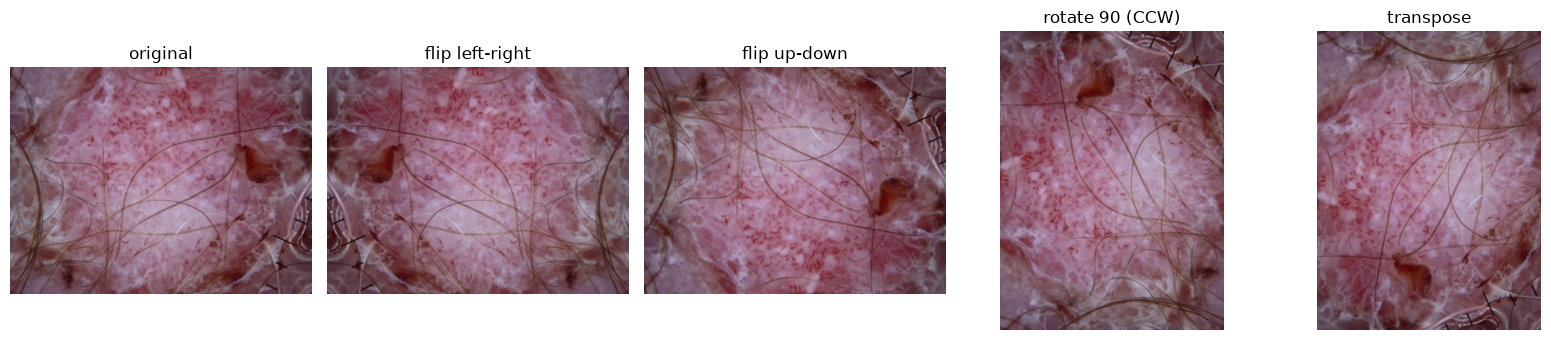

,operation,shape,identical to Pillow,view (shares memory)
0,flip left-right,"(450, 600, 3)",True,True
1,flip up-down,"(450, 600, 3)",True,True
2,rotate 90 (CCW),"(600, 450, 3)",True,True
3,transpose,"(600, 450, 3)",True,True


In [5]:
avail = images[images["available"]]
sample_id = avail[avail.image_type == "dermoscopic"]["isic_id"].iloc[0]
pil_img = Image.open(config.image_path(sample_id)).convert("RGB")
arr = np.asarray(pil_img).copy()                     # (H, W, 3) uint8, owns its memory
print(sample_id, arr.shape, arr.dtype)

np_ops = {
    "flip left-right": lambda a: a[:, ::-1],                 # reverse the column axis
    "flip up-down":    lambda a: a[::-1],                    # reverse the row axis
    "rotate 90 (CCW)": lambda a: a.transpose(1, 0, 2)[::-1], # transpose, then reverse rows
    "transpose":       lambda a: a.transpose(1, 0, 2),       # swap rows and columns
}
pil_ops = {
    "flip left-right": Image.Transpose.FLIP_LEFT_RIGHT,
    "flip up-down":    Image.Transpose.FLIP_TOP_BOTTOM,
    "rotate 90 (CCW)": Image.Transpose.ROTATE_90,
    "transpose":       Image.Transpose.TRANSPOSE,
}
rows = []
fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
axes[0].imshow(arr); axes[0].set_title("original")
for ax, (name, f) in zip(axes[1:], np_ops.items()):
    out = f(arr)
    ref = np.asarray(pil_img.transpose(pil_ops[name]))
    assert np.array_equal(out, ref), name
    rows.append({"operation": name, "shape": out.shape, "identical to Pillow": np.array_equal(out, ref),
                 "view (shares memory)": np.shares_memory(out, arr)})
    ax.imshow(out); ax.set_title(name)
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()
pd.DataFrame(rows)

(b) All four are **views**: they only change strides/offset, no pixel is copied (`np.shares_memory` is True in the table). `np.ascontiguousarray` or `.copy()` would create a copy. Writing into a view therefore modifies the original:

In [6]:
demo = arr.copy()
view = demo[:, ::-1]                       # left-right flip = view
view[0, 0] = [255, 0, 0]                   # write the first pixel of the VIEW...
print("original top-RIGHT pixel is now:", demo[0, -1], "-> the original changed")
copy = np.ascontiguousarray(demo[:, ::-1]); copy[0, 0] = [0, 255, 0]
print("after writing into a COPY, original top-right pixel:", demo[0, -1], "| shares_memory:", np.shares_memory(copy, demo))

original top-RIGHT pixel is now: [255   0   0] -> the original changed
after writing into a COPY, original top-right pixel: [255   0   0] | shares_memory: False


(c) Memory budget for all 10,480 images. Sizes are read from the JPEG headers (no decoding).

In [7]:
def header_size(isic_id):
    with Image.open(config.image_path(isic_id)) as im:
        return im.size                                # (W, H) without decoding the pixels

sizes = np.array([header_size(i) for i in avail["isic_id"]])
n_all = len(images)
px_known = (sizes[:, 0] * sizes[:, 1]).sum()
px_total = px_known * n_all / len(sizes)               # = exact when all files are present
if len(sizes) < n_all:
    print(f"only {len(sizes)} files on disk -> extrapolating their mean size to {n_all} images")
GB = 1024 ** 3
budget = pd.DataFrame({
    "uint8 (1 B/value)": [px_total * 3 / GB, n_all * 224 * 224 * 3 / GB],
    "float32 (4 B/value)": [px_total * 3 * 4 / GB, n_all * 224 * 224 * 3 * 4 / GB],
}, index=["original resolution", "224 x 224"]).round(2)
print("RAM needed (GiB):"); budget

RAM needed (GiB):


,uint8 (1 B/value),float32 (4 B/value)
original resolution,7.91,31.62
224 x 224,1.47,5.88


**Answer A2.1c.** The images are about 600x450 (see the B1 size table), so keeping the whole set at full resolution needs about 8.0 GiB as uint8 and about 32 GiB as float32. At 224x224 it is about 1.5 GiB (uint8) and 5.9 GiB (float32). On a 16 GB laptop only the 224x224 uint8 version would fit comfortably, and float32 at full resolution is impossible. Pre-loading is not needed anyway: the `Dataset` reads and decodes each JPEG **lazily** in `__getitem__`, the `DataLoader` workers do it in parallel, and only one batch (32x3x224x224 float32 is about 19 MB) is in RAM at a time. If disk reading became the bottleneck, I would cache resized 256-px uint8 copies on disk rather than loading everything into memory.

### A2.2 JPEG compression, and a shortcut hiding in the file size
(a) Re-encoding one image in memory.

original file: 41.5 KB


,quality,size_KB,PSNR_dB
0,95,73.04,51.23
1,75,38.43,65.35
2,50,30.00,35.85
3,25,17.41,33.22
4,10,9.41,29.24


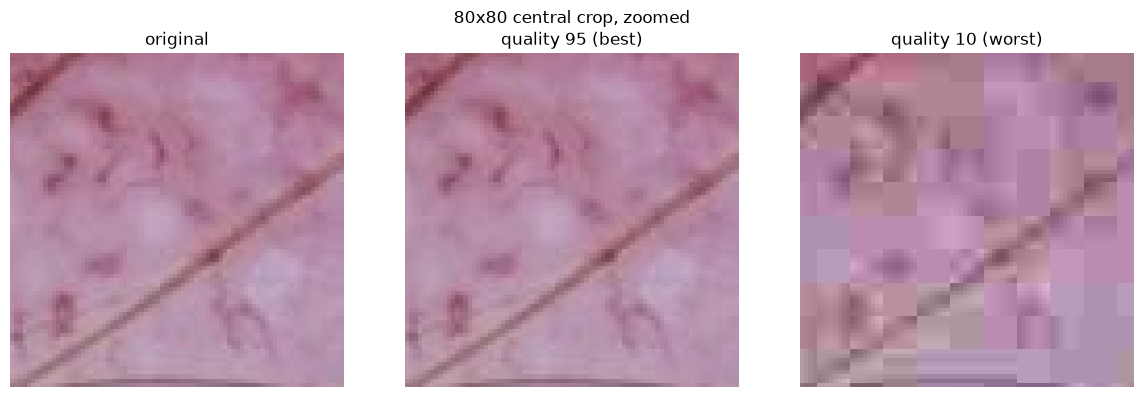

In [8]:
def psnr(a: np.ndarray, b: np.ndarray, max_val: float = 255.0) -> float:
    """Peak signal-to-noise ratio in dB, implemented from the definition 10*log10(MAX^2 / MSE)."""
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return float("inf") if mse == 0 else 10 * np.log10(max_val ** 2 / mse)

orig_bytes = config.image_path(sample_id).stat().st_size
recoded, rows = {}, []
for q in (95, 75, 50, 25, 10):
    buf = io.BytesIO()
    pil_img.save(buf, format="JPEG", quality=q)
    rec = np.asarray(Image.open(io.BytesIO(buf.getvalue())).convert("RGB"))
    recoded[q] = rec
    rows.append({"quality": q, "size_KB": buf.tell() / 1024, "PSNR_dB": psnr(arr, rec)})
jpeg_tab = pd.DataFrame(rows).round(2)
print(f"original file: {orig_bytes / 1024:.1f} KB"); display(jpeg_tab)

h, w = arr.shape[:2]
crop = (slice(h // 2 - 40, h // 2 + 40), slice(w // 2 - 40, w // 2 + 40))     # 80x80 zoom
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (title, im) in zip(axes, [("original", arr), ("quality 95 (best)", recoded[95]), ("quality 10 (worst)", recoded[10])]):
    ax.imshow(im[crop], interpolation="nearest"); ax.set_title(title); ax.axis("off")
plt.suptitle("80x80 central crop, zoomed"); plt.tight_layout(); plt.show()

**(a) observation.** Something unexpected shows up in this image: re-encoding at quality 75 gives a *higher* PSNR (about 65 dB) than quality 95 (about 51 dB), and quality 95 produces a file almost twice as large as the original (73 vs 41.5 KB). The original was most likely saved at about quality 75, so re-quantising with the same tables is almost lossless, while any other quality re-quantises blocks that were already quantised. A higher quality setting cannot bring back what was lost. Below quality 50 the PSNR drops steadily, and blocking and colour bleeding are visible in the quality-10 crop.

**(b) Implications.** The MILK10k files are already JPEG, so every image carries 8x8 block artefacts and chroma subsampling whose strength depends on the camera or software that saved it. A CNN can learn those artefacts if their strength correlates with the label (via the contributor or device). Re-saving (double compression) adds more artefacts, so we never re-encode the training data and we keep augmentation in memory. Resizing *after* compression (600x450 to 224) smooths most block artefacts, which helps. Because images from different sources may be compressed differently, a quality setting could still act as a source fingerprint. That is exactly what part (c) checks.

(c) File size as a malignancy score (no decoding: `os.stat`).

file sizes read for 10234 Benign/Malignant images


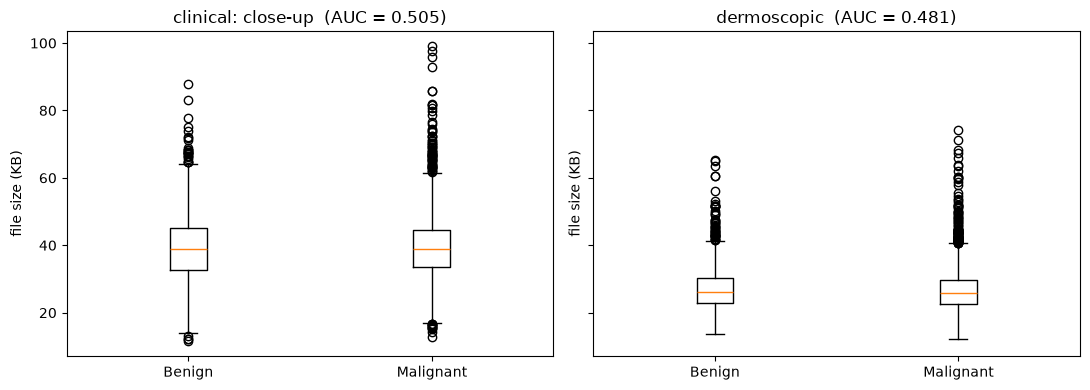

,image_type,n,median_KB_benign,median_KB_malignant,ROC_AUC,verdict
0,clinical: close-up,5117,38.775,38.802,0.505,~ chance
1,dermoscopic,5117,26.187,25.815,0.481,~ chance


In [9]:
from sklearn.metrics import roc_auc_score

fs = images[images["available"]].copy()
fs["file_KB"] = [os.stat(config.image_path(i)).st_size / 1024 for i in fs["isic_id"]]
fs = fs[fs["diagnosis_1"].isin(["Benign", "Malignant"])]
fs["malignant"] = (fs["diagnosis_1"] == "Malignant").astype(int)
print(f"file sizes read for {len(fs)} Benign/Malignant images")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
auc_rows = []
for ax, (itype, g) in zip(axes, fs.groupby("image_type")):
    ax.boxplot([g.loc[g.malignant == 0, "file_KB"], g.loc[g.malignant == 1, "file_KB"]])
    ax.set_xticks([1, 2], ["Benign", "Malignant"])
    auc = roc_auc_score(g["malignant"], g["file_KB"])
    ax.set_title(f"{itype}  (AUC = {auc:.3f})"); ax.set_ylabel("file size (KB)")
    auc_rows.append({"image_type": itype, "n": len(g), "median_KB_benign": g.loc[g.malignant == 0, "file_KB"].median(),
                     "median_KB_malignant": g.loc[g.malignant == 1, "file_KB"].median(), "ROC_AUC": auc,
                     "verdict": "shortcut signal" if abs(auc - 0.5) > 0.05 else "~ chance"})
plt.tight_layout(); plt.show()
pd.DataFrame(auc_rows).round(3)

**Answer A2.2c.** File size needs no pixel decoding and knows nothing about the lesion, so any AUC away from 0.5 would be a **shortcut**: information about how the image was taken, not what it shows. On the full dataset there is **no file-size shortcut**: ROC-AUC = 0.505 for clinical close-ups and 0.481 for dermoscopic images (10,234 Benign/Malignant images), and the median sizes of Benign and Malignant images differ by less than 0.4 KB. This is consistent with B1: every image is exactly 600x450, so all images were exported in the same, standardised way (same resolution and probably the same JPEG settings), which removes the most common acquisition fingerprints. If a shortcut existed it would come from acquisition factors such as the device and its JPEG quality, the resolution before export, the contributing centre, cropping or "altered" images, or from content (hair, vignette, how much of the frame the lesion fills). A null result for this crude feature does not prove that no acquisition shortcut exists (colour calibration or contributor-specific framing could still leak), so we keep decoding and resizing everything identically and will check model errors against contributor and `image_manipulation` later.

---
## A3. Session 3 — Splits, imbalance, leakage, augmentation, datasets
### A3.1 Measure the leak (do not only count it)
Random forest on **metadata only** (age, sex, site, image_type) predicting diagnosis_1. Imputation and one-hot encoding are inside the Pipeline, so they are fitted on the training part only.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

FEATURES_NUM = ["age_approx"]
FEATURES_CAT = ["sex", "anatom_site_general", "image_type"]
TARGET = "diagnosis_1"

def make_rf(seed):
    pre = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), FEATURES_NUM),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="unknown")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore"))]), FEATURES_CAT),
    ])
    rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=1, random_state=seed, n_jobs=-1)
    return Pipeline([("pre", pre), ("rf", rf)])

def naive_split(df, seed):
    return train_test_split(df.index, test_size=0.2, stratify=df[TARGET], random_state=seed)

def grouped_split(df, seed):
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    tr, te = next(sgkf.split(df, df[TARGET], groups=df["lesion_id"]))
    return df.index[tr], df.index[te]

# sibling of every image = the other image of the same lesion
sib = images.groupby("lesion_id")["isic_id"].transform(lambda s: s.iloc[::-1].values)
images["sibling_id"] = sib

def sibling_oracle(df, tr_idx, te_idx):
    """Predict a test image with its sibling's label if the sibling is in train, else the train majority class."""
    train_ids = set(df.loc[tr_idx, "isic_id"])
    label_of = df.set_index("isic_id")[TARGET]
    majority = df.loc[tr_idx, TARGET].mode()[0]
    te = df.loc[te_idx]
    sib_in_train = te["sibling_id"].isin(train_ids)
    pred = np.where(sib_in_train, te["sibling_id"].map(label_of), majority)
    return balanced_accuracy_score(te[TARGET], pred), 100 * sib_in_train.mean()

rows = []
for seed in range(5):
    for name, splitter in [("naive (image-level)", naive_split), ("grouped (lesion_id)", grouped_split)]:
        tr, te = splitter(images, seed)
        model = make_rf(seed).fit(images.loc[tr, FEATURES_NUM + FEATURES_CAT], images.loc[tr, TARGET])
        ba_rf = balanced_accuracy_score(images.loc[te, TARGET], model.predict(images.loc[te, FEATURES_NUM + FEATURES_CAT]))
        ba_or, pct_sib = sibling_oracle(images, tr, te)
        rows.append({"split": name, "seed": seed, "RF_bal_acc": ba_rf, "oracle_bal_acc": ba_or,
                     "pct_test_with_sibling_in_train": pct_sib})
leak = pd.DataFrame(rows)
leak_summary = leak.groupby("split")[["RF_bal_acc", "oracle_bal_acc", "pct_test_with_sibling_in_train"]].agg(["mean", "std"]).round(3)
leak_summary

RF_bal_acc        oracle_bal_acc        pct_test_with_sibling_in_train       
                          mean    std           mean    std                           mean    std
split                                                                                            
grouped (lesion_id)      0.426  0.003          0.333  0.000                           0.00  0.000
naive (image-level)      0.426  0.004          0.847  0.022                          79.79  1.211

**Answer A3.1d.** The leak does **not** inflate the random forest: balanced accuracy is 0.426 +- 0.004 with the naive split and 0.426 +- 0.003 with the grouped split, the same number. The reason is *what* the two images of a lesion share in this feature space. They share age, sex and site, but these values are shared by hundreds of other lesions too (age is rounded to 5 years, there are only a few sites and two sexes). The only feature that differs, `image_type`, carries no label information. Memorising the sibling is therefore almost the same as memorising its whole metadata group: weak information. The oracle shows the *potential* of the leak. With the naive split 79.8% of test images have their sibling in train, and simply copying the sibling's label reaches a balanced accuracy of **0.85**, double the RF. With the grouped split 0% have their sibling in train and the oracle falls back to "always Malignant" (0.333). A CNN *can* recognise a lesion: the two views share shape, colour and the surrounding skin, and near-duplicate photos are even easier. So an image model on a naive split could approach the oracle and report a score that is really lesion recognition, not diagnosis. "I measured no inflation" with a weak model says nothing about a strong one, so the grouped split is a design rule, not something we switch on once a leak has been observed.

### A3.2 A reusable three-way split
`split_lesions()` is in `milk10k_pipeline/splits.py` (StratifiedGroupKFold on the lesion table, groups = lesion_id; one fold held out as test, then one fold of the rest as val). Property test over 10 seeds:

In [11]:
import inspect
print(inspect.getsource(splits.split_lesions).split('"""')[0] + "...")

VAL, TEST = 0.15, 0.15
rare = ["MAL_OTH", "DF", "INF", "VASC", "BEN_OTH"]
presence = {c: 0 for c in rare}
size_rows = []
for seed in range(10):
    tr, va, te = splits.split_lesions(lesions, VAL, TEST, seed)
    sizes = splits.check_split(tr, va, te, len(lesions), VAL, TEST, tol_pp=1.0)   # overlap + size asserts
    assert splits.split_lesions(lesions, VAL, TEST, seed) == (tr, va, te)         # reproducible
    dx_va = set(lesions.loc[lesions.lesion_id.isin(va), "dx"])
    dx_te = set(lesions.loc[lesions.lesion_id.isin(te), "dx"])
    for c in rare:
        presence[c] += (c in dx_va) and (c in dx_te)
    size_rows.append({"seed": seed, **{k: round(v, 2) for k, v in sizes.items()}})
assert splits.split_lesions(lesions, VAL, TEST, 0) != splits.split_lesions(lesions, VAL, TEST, 1)
print("all 10 seeds: no overlap, sizes within +-1 pp, same seed -> identical output")
display(pd.DataFrame(size_rows).set_index("seed").T)
print("seeds (out of 10) where the class is present in BOTH val and test:")
pd.Series(presence, name="n_seeds").to_frame().assign(n_lesions=lesions.dx.value_counts()[rare])

def split_lesions(lesions: pd.DataFrame, val_size: float = 0.15, test_size: float = 0.15,
                  seed: int = 42, label_col: str = "dx") -> Tuple[List[str], List[str], List[str]]:
    ...
all 10 seeds: no overlap, sizes within +-1 pp, same seed -> identical output


seed,0,1,2,3,4,5,6,7,8,9
train,71.41,71.41,71.41,71.41,71.41,71.41,71.41,71.41,71.41,71.41
val,14.29,14.29,14.29,14.29,14.29,14.29,14.29,14.29,14.29,14.29
test,14.29,14.29,14.29,14.29,14.29,14.29,14.29,14.29,14.29,14.29


seeds (out of 10) where the class is present in BOTH val and test:


,n_seeds,n_lesions
MAL_OTH,10,9
DF,10,52
INF,10,50
VASC,10,47
BEN_OTH,10,44


**Answer A3.2.** Thanks to stratification, all five rare classes are present in both val and test for **10 of 10 seeds**. Presence is not the same as evaluability, though. DF, INF, VASC and BEN_OTH get only about 6-8 lesions per held-out split, and MAL_OTH (9 lesions in total) gets **1 or 2**. Any per-class metric for MAL_OTH is then based on one or two cases: its recall can only take the values 0, 50 or 100%, and a single error changes macro-F1 noticeably. The rarest class cannot be *evaluated* reliably on a single held-out split. It should be reported with its raw counts and a confidence interval, pooled across cross-validation folds, or (as in our label strategy) merged into a broader group for the main metric.

### A3.3 Why StratifiedGroupKFold?

In [12]:
from sklearn.model_selection import GroupKFold, StratifiedKFold

def fold_report(name, df, folds, unit):
    leaked, props, absent = 0, [], 0
    for tr, va in folds:
        leaked += len(set(df.iloc[tr]["lesion_id"]) & set(df.iloc[va]["lesion_id"]))
        p = df.iloc[va]["dx"].value_counts(normalize=True) * 100
        props.append(p)
        absent += int("MAL_OTH" not in p.index)
    P = pd.DataFrame(props).fillna(0)
    spread = P.max() - P.min()
    return {"strategy": name, "table": unit, "leaked lesions (sum over folds)": leaked,
            "largest class-% spread across val folds (pp)": round(spread.max(), 2),
            "class with that spread": spread.idxmax(),
            "folds without MAL_OTH in val": absent}

k = 5
res = [
    fold_report("(i) GroupKFold", lesions,
                GroupKFold(n_splits=k).split(lesions, lesions["dx"], groups=lesions["lesion_id"]), "lesions"),
    fold_report("(ii) StratifiedKFold", images,
                StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED).split(images, images["dx"]), "images"),
    fold_report("(iii) StratifiedGroupKFold", lesions,
                StratifiedGroupKFold(n_splits=k, shuffle=True, random_state=SEED).split(lesions, lesions["dx"], groups=lesions["lesion_id"]), "lesions"),
]
pd.DataFrame(res).set_index("strategy")

,table,leaked lesions (sum over folds),largest class-% spread across val folds (pp),class with that spread,folds without MAL_OTH in val
strategy,,,,,
(i) GroupKFold,lesions,0,3.63,NV,0
(ii) StratifiedKFold,images,8316,0.05,BCC,0
(iii) StratifiedGroupKFold,lesions,0,0.10,BCC,0


**Answer A3.3.** StratifiedKFold on images has the smallest spread (0.05 pp) but leaks 8,316 lesions summed over the 5 folds (about 80% of each validation fold has its sibling in training). GroupKFold is leak-free but ignores the labels, so class proportions drift by up to 3.6 pp between folds (NV). **StratifiedGroupKFold** gives both zero leakage and a spread of only 0.10 pp, with MAL_OTH in every validation fold, so it is the one used in the project.

### A3.4 Metrics and the cost of errors
Test split at lesion level (same call and seed as the project split, `scripts/05_make_splits.py`), target diagnosis_1.

train 3742 lesions, test 749 lesions; test mix: {'Malignant': 519, 'Benign': 213, 'Indeterminate': 17}


,pred Benign,pred Indeterminate,pred Malignant
true Benign,0,1,1
true Indeterminate,5,0,5
true Malignant,50,5,0


,accuracy,balanced_accuracy,macro_F1,expected_cost_per_lesion
predictor,,,,
always-Malignant,0.693,0.333,0.273,0.398
always-Benign,0.284,0.333,0.148,34.760
stratified-random,0.553,0.343,0.344,10.988
uniform-random,0.331,0.357,0.265,14.296


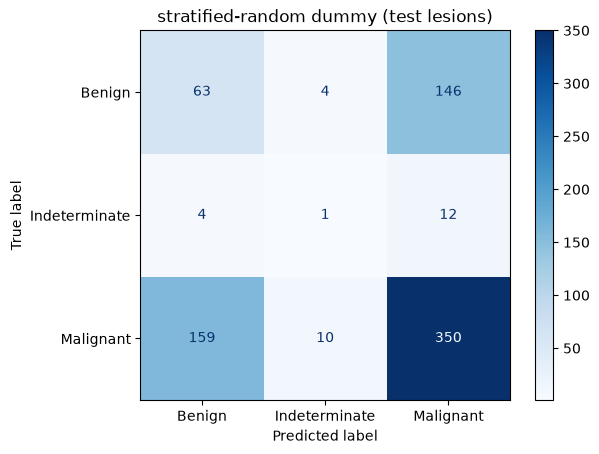

Benign           34.805
Indeterminate     3.751
Malignant         0.400
rank by accuracy: ['always-Malignant', 'stratified-random', 'uniform-random', 'always-Benign']
rank by cost    : ['always-Malignant', 'stratified-random', 'uniform-random', 'always-Benign']


In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, ConfusionMatrixDisplay

CLASSES = config.PRIMARY_CLASSES          # ["Benign", "Indeterminate", "Malignant"]
les_s = lesions.assign(strat=splits.make_strat_key(lesions))
tr_ids, va_ids, te_ids = splits.split_lesions(les_s, config.VAL_SIZE, config.TEST_SIZE, SEED, label_col="strat")
train_l = lesions[lesions.lesion_id.isin(tr_ids)]
test_l = lesions[lesions.lesion_id.isin(te_ids)]
X_tr, y_tr = np.zeros((len(train_l), 1)), train_l["diagnosis_1"]
X_te, y_te = np.zeros((len(test_l), 1)), test_l["diagnosis_1"]
print(f"train {len(train_l)} lesions, test {len(test_l)} lesions; test mix: {y_te.value_counts().to_dict()}")

dummies = {
    "always-Malignant": DummyClassifier(strategy="constant", constant="Malignant"),
    "always-Benign": DummyClassifier(strategy="constant", constant="Benign"),
    "stratified-random": DummyClassifier(strategy="stratified", random_state=SEED),
    "uniform-random": DummyClassifier(strategy="uniform", random_state=SEED),
}
preds = {name: d.fit(X_tr, y_tr).predict(X_te) for name, d in dummies.items()}

# cost matrix: rows = truth, columns = prediction (order Benign, Indeterminate, Malignant)
COST = pd.DataFrame([[0, 1, 1],      # Benign:        unnecessary work-up / follow-up costs 1
                     [5, 0, 5],      # Indeterminate: any error costs 5 (missed pre-cancer or wrong pathway)
                     [50, 5, 0]],    # Malignant:     missed cancer 50; "only monitor" 5
                    index=[f"true {c}" for c in CLASSES], columns=[f"pred {c}" for c in CLASSES])
display(COST)

def expected_cost(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=CLASSES)
    return (cm * COST.values).sum() / len(y_true)

metric_rows = [{"predictor": n, "accuracy": accuracy_score(y_te, p),
                "balanced_accuracy": balanced_accuracy_score(y_te, p),
                "macro_F1": f1_score(y_te, p, average="macro", labels=CLASSES, zero_division=0),
                "expected_cost_per_lesion": expected_cost(y_te, p)} for n, p in preds.items()]
metrics = pd.DataFrame(metric_rows).set_index("predictor").round(3)
display(metrics)

ConfusionMatrixDisplay.from_predictions(y_te, preds["stratified-random"], labels=CLASSES, cmap="Blues")
plt.title("stratified-random dummy (test lesions)"); plt.show()

# best constant prediction under the cost matrix = argmin over columns of  prior @ cost
prior = y_tr.value_counts(normalize=True).reindex(CLASSES).values
const_cost = pd.Series(prior @ COST.values, index=CLASSES, name="expected cost if always predicting")
print(const_cost.round(3).to_string())
print("rank by accuracy:", list(metrics["accuracy"].sort_values(ascending=False).index))
print("rank by cost    :", list(metrics["expected_cost_per_lesion"].sort_values().index))

**Answer A3.4.** *(a)* None of the dummies has any skill: balanced accuracy is about 1/3 for all of them, but plain accuracy rewards always-Malignant (about 69%) only because Malignant is the majority class. Macro-F1 exposes this (it collapses for the constant predictors). *(b)/(c)* With the cost matrix above (a missed cancer costs 50, an unnecessary work-up 1, Indeterminate errors 5), the expected costs per lesion are: always-Malignant **0.40**, stratified-random 10.99, uniform-random 14.30 and always-Benign **34.76**. The optimal **constant** prediction is **Malignant** (prior x cost: 0.40 vs 3.75 for Indeterminate and 34.8 for Benign). For these four dummies the two rankings happen to agree, but that is a coincidence of the class mix, not a property of the metrics. Accuracy treats a missed cancer and an unnecessary biopsy as equally bad, so a predictor that trades a few missed cancers for many correct benign calls could gain accuracy while becoming much more expensive. With costs this asymmetric (50:1) the decision threshold must be chosen on cost or Malignant recall, not on accuracy. Note also that "always Malignant" is only cheap *here* because 69% of MILK10k lesions are malignant. In a real clinic, where most lesions are benign, it would mean biopsying everyone.

### A3.5 Is this augmentation label-safe? A quantitative audit
(a) Lesion pixels are segmented with an Otsu threshold (`color_analysis.lesion_mask`). Hue is converted to degrees and averaged with a **circular** mean (350 deg and 10 deg average to 0 deg, not 180 deg).

In [14]:
import torch
from torchvision.transforms import ColorJitter

N_PER_GROUP = 100
derm_av = images[(images.image_type == "dermoscopic") & images.available]
groups = {g: derm_av[derm_av.diagnosis_1 == g].sample(min(N_PER_GROUP, (derm_av.diagnosis_1 == g).sum()),
                                                      random_state=SEED)
          for g in ("Benign", "Malignant")}
print({g: len(d) for g, d in groups.items()}, "dermoscopic images per group")

cache = {}           # isic_id -> (rgb array, lesion mask), reused for the jitter experiment
stats = {}
for g, d in groups.items():
    hv = []
    for i in d["isic_id"]:
        rgb = np.asarray(Image.open(config.image_path(i)).convert("RGB"))
        m = ca.lesion_mask(rgb)
        cache[i] = (rgb, m)
        hv.append(ca.lesion_hue_value(rgb, m))
    hv = np.array(hv)
    stats[g] = {"hue_circ_mean_deg": ca.circular_mean_deg(hv[:, 0]), "V_mean": hv[:, 1].mean(),
                "V_std_between_images": hv[:, 1].std()}
gap_hue = ca.circular_diff_deg(stats["Benign"]["hue_circ_mean_deg"], stats["Malignant"]["hue_circ_mean_deg"])
gap_v = abs(stats["Benign"]["V_mean"] - stats["Malignant"]["V_mean"])
display(pd.DataFrame(stats).round(2))
print(f"CLASS GAP  hue: {gap_hue:.2f} deg   brightness V: {gap_v:.2f} (0-255 scale)")

{'Benign': 100, 'Malignant': 100} dermoscopic images per group


,Benign,Malignant
hue_circ_mean_deg,3.21,359.76
V_mean,135.86,145.89
V_std_between_images,30.30,31.98


CLASS GAP  hue: 3.45 deg   brightness V: 10.03 (0-255 scale)


In [15]:
def jitter_effect(param, value, ids, seed=SEED):
    """Mean |change| of lesion hue (deg) and V when ColorJitter(param=value) is applied to each image."""
    torch.manual_seed(seed)
    cj = ColorJitter(**{param: value})
    dh, dv = [], []
    for i in ids:
        rgb, m = cache[i]
        h0, v0 = ca.lesion_hue_value(rgb, m)
        h1, v1 = ca.lesion_hue_value(np.asarray(cj(Image.fromarray(rgb))), m)
        dh.append(ca.circular_diff_deg(h0, h1)); dv.append(abs(v1 - v0))
    return np.mean(dh), np.mean(dv)

all_ids = list(cache)
audit = []
for h in (0.02, 0.05, 0.1, 0.5):
    dh, dv = jitter_effect("hue", h, all_ids)
    audit.append({"augmentation": f"hue={h}", "max shift (deg)": h * 360, "mean |d hue| (deg)": dh,
                  "mean |d V|": dv, "changes colour MORE than class gap": dh > gap_hue})
for b in (0.1, 0.3, 0.6):
    dh, dv = jitter_effect("brightness", b, all_ids)
    audit.append({"augmentation": f"brightness={b}", "max shift (deg)": 0.0, "mean |d hue| (deg)": dh,
                  "mean |d V|": dv, "changes colour MORE than class gap": dv > gap_v})
audit = pd.DataFrame(audit).round(2)
print(f"class gap: hue {gap_hue:.2f} deg, V {gap_v:.2f}")
audit

class gap: hue 3.45 deg, V 10.03


,augmentation,max shift (deg),mean |d hue| (deg),mean |d V|,changes colour MORE than class gap
0,hue=0.02,7.2,3.18,0.00,False
1,hue=0.05,18.0,8.82,0.00,True
2,hue=0.1,36.0,18.11,0.00,True
3,hue=0.5,180.0,94.20,0.00,True
4,brightness=0.1,0.0,0.06,7.66,False
5,brightness=0.3,0.0,0.06,22.63,True
6,brightness=0.6,0.0,0.39,43.64,True


**Answer A3.5b.** On 100 + 100 dermoscopic images the Benign-Malignant gap in mean lesion colour is small: **3.45 deg of hue** and **10.0 units of V** (Malignant lesions are slightly brighter, V 145.9 vs 135.9). The within-class spread of V (std of about 30-32) is three times larger than that gap. **Hue:** hue=0.02 already shifts the lesion hue by 3.2 deg on average, almost the whole class gap, and from hue=0.05 on (8.8 deg, 18 deg, 94 deg) the jitter changes colour **more** than the difference between the classes; hue=0.5 turns red into green or blue. Colour is diagnostic (blue-white veil, red vessels, brown network), so hue jitter is **switched off** in the project. **Brightness:** 0.1 changes V by 7.7 on average, below the class gap and far below the natural variation inside each class, so it only simulates normal lighting differences and is kept. 0.3 (22.6) and 0.6 (43.6) exceed the gap and produce unrealistic exposures, so they are rejected. Safe: flips, 90-degree rotations, moderate crops/zoom (lesions have no canonical orientation) and mild brightness/contrast. Risky: hue, strong saturation or brightness, heavy crops that may cut the lesion border, and elastic/shape distortions (asymmetry and border are diagnostic criteria). The final list must be **approved by a dermatologist** (the clinical owner of the label), with this quantitative audit as the evidence, not decided by the ML engineer alone.

### A3.6 A lesion-level Dataset
`LesionDataset` and `aggregate_predictions` are in `milk10k_pipeline/datasets.py` (importable, reused in the project).

In [16]:
from torch.utils.data import DataLoader
from milk10k_pipeline.datasets import LesionDataset, aggregate_predictions
from milk10k_pipeline.transforms import eval_transform, train_transform
print(inspect.getsource(LesionDataset.__getitem__))

both_ok = data.available_mask(lesions["derm_id"]) & data.available_mask(lesions["clinical_id"])
les_av = lesions[both_ok].reset_index(drop=True)
print(f"lesions with both images on disk: {len(les_av)}")

# missing image -> clear error
try:
    LesionDataset(pd.DataFrame({"lesion_id": ["X"], "derm_id": ["ISIC_missing"], "clinical_id": ["ISIC_missing2"],
                                "diagnosis_1": ["Benign"]}))
except FileNotFoundError as e:
    print("missing file ->", e)

# (a) one batch of 8: shapes + lesion_ids match the table
ds8 = LesionDataset(les_av.head(8), label_col="diagnosis_1", transform=eval_transform())
batch = next(iter(DataLoader(ds8, batch_size=8, shuffle=False)))
for v in ("derm", "clinical"):
    print(v, tuple(batch[v].shape), batch[v].dtype)
    assert batch[v].shape == (8, 3, config.IMG_SIZE, config.IMG_SIZE)
assert list(batch["lesion_id"]) == les_av.head(8)["lesion_id"].tolist()
assert batch["label"].tolist() == [ds8.classes.index(c) for c in les_av.head(8)["diagnosis_1"]]
print("(a) OK - shapes (8, 3, H, W) per view, lesion_ids and labels match the table")

# the transform is applied independently to each view: with train_transform the same image gives different draws
ds_aug = LesionDataset(les_av.head(1), label_col="diagnosis_1", transform=train_transform())
x1, x2 = ds_aug[0]["derm"], ds_aug[0]["derm"]
print("two draws of the same derm view identical?", torch.equal(x1, x2))

    def __getitem__(self, idx: int) -> Dict:
        row = self.df.iloc[idx]
        item = {}
        for v in self.views:
            img = _load_rgb(self.img_dir / f"{row[VIEW_TO_COLUMN[v]]}.jpg")
            item[v] = self.transform(img) if self.transform is not None else img
        item["label"] = int(self.labels[idx])
        item["lesion_id"] = row["lesion_id"]
        return item

lesions with both images on disk: 5240
missing file -> [LesionDataset[derm]] 1 of 1 image files are missing in C:\Users\Dell\OneDrive\Desktop\EADA\4th Year\Computer Vision & Speech Recognition\milk10k_project\images (e.g. ISIC_missing). Pass allow_missing=True to drop them explicitly.
derm (8, 3, 224, 224) torch.float32
clinical (8, 3, 224, 224) torch.float32
(a) OK - shapes (8, 3, H, W) per view, lesion_ids and labels match the table
two draws of the same derm view identical? False


In [17]:
# (b) one epoch over 800 lesions: class counts seen == class counts of the subset
n_sub = min(800, len(les_av))
if n_sub < 800:
    print(f"only {len(les_av)} lesions have both images on disk -> using {n_sub}")
subset = les_av.sample(n_sub, random_state=SEED).reset_index(drop=True)
ds = LesionDataset(subset, label_col="diagnosis_1", transform=eval_transform(), views=("derm", "clinical"))
dl = DataLoader(ds, batch_size=8, shuffle=True, num_workers=0)
seen = {}
t0 = time.perf_counter()
seen_ids = []
for b in dl:
    for lab in b["label"].tolist():
        seen[ds.classes[lab]] = seen.get(ds.classes[lab], 0) + 1
    seen_ids += list(b["lesion_id"])
expected = subset["diagnosis_1"].value_counts().to_dict()
print(f"epoch over {len(ds)} lesions in {time.perf_counter() - t0:.1f}s")
print("seen    :", dict(sorted(seen.items())))
print("expected:", dict(sorted(expected.items())))
assert seen == expected and sorted(seen_ids) == sorted(subset["lesion_id"])
print("(b) OK - every lesion seen exactly once, class counts match")

epoch over 800 lesions in 14.7s
seen    : {'Benign': 207, 'Indeterminate': 22, 'Malignant': 571}
expected: {'Benign': 207, 'Indeterminate': 22, 'Malignant': 571}
(b) OK - every lesion seen exactly once, class counts match


In [18]:
# (c) aggregate_predictions with synthetic probabilities
print(inspect.getsource(aggregate_predictions).split('"""')[0])
rng = np.random.default_rng(SEED)
img_tab = images[images.lesion_id.isin(lesions.lesion_id.head(50))][["isic_id", "lesion_id"]].reset_index(drop=True)
probs = rng.dirichlet(np.ones(3), size=len(img_tab))                  # random image-level probabilities
agg = aggregate_predictions(probs, img_tab, CLASSES)

# reference computed by hand for every lesion
for lid, idx in img_tab.groupby("lesion_id").groups.items():
    ref = probs[list(idx)].mean(axis=0)
    assert np.allclose(agg.loc[lid, [f"p_{c}" for c in CLASSES]], ref)
    assert agg.loc[lid, "pred"] == ref.argmax()
assert len(agg) == img_tab.lesion_id.nunique() and (agg["n_images"] == 2).all()
assert np.allclose(agg[[f"p_{c}" for c in CLASSES]].sum(axis=1), 1)
# hand-made case where the two views disagree: average decides
toy = aggregate_predictions(np.array([[0.9, 0.0, 0.1], [0.2, 0.0, 0.8]]), pd.DataFrame({"lesion_id": ["L", "L"]}), CLASSES)
assert toy.loc["L", "pred"] == 0                                       # mean = [0.55, 0, 0.45] -> Benign
print("(c) OK"); agg.head()

def aggregate_predictions(image_probs: np.ndarray, image_table: pd.DataFrame,
                          class_names: Optional[Sequence[str]] = None) -> pd.DataFrame:
    
(c) OK


,p_Benign,p_Indeterminate,p_Malignant,n_images,pred
lesion_id,,,,,
IL_0000652,0.095027,0.493031,0.411942,2,1
IL_0003176,0.535761,0.262267,0.201973,2,0
IL_0004688,0.077728,0.707694,0.214577,2,1
IL_0005081,0.358419,0.347186,0.294395,2,0
IL_0006177,0.402647,0.224622,0.372731,2,0


**Answer A3.6d.** The correct unit of evaluation is the **lesion**. The clinical decision (biopsy or not) is taken per lesion, the label is defined per lesion, and the split is grouped by lesion, so each test lesion gets one prediction (here the average of its two views) and one entry in the confusion matrix. Evaluating per image counts every lesion twice, so the two views' errors are correlated and the confidence intervals are falsely narrow. It also mixes the easier and harder view into one number, and if the split were not grouped, one view in training makes the other view in test a near-memorised case, inflating every metric. Per-image scores can be reported as a diagnostic (dermoscopic vs clinical), never as the headline result.